In [ ]:
#Install Libraries
!pip install pyspark

In [ ]:
#Import Libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import matplotlib.pyplot as plt

In [ ]:
#Create Spark Session
spark = SparkSession.builder.appName("Ecommerce Big Data Analysis").getOrCreate()

print("Spark Started Successfully")

Spark Started Successfully


In [ ]:
#Load Dataset
orders = spark.read.csv("olist_orders_dataset.csv", header=True, inferSchema=True)

customers = spark.read.csv("olist_customers_dataset.csv", header=True, inferSchema=True)

order_items = spark.read.csv("olist_order_items_dataset.csv", header=True, inferSchema=True)

products = spark.read.csv("olist_products_dataset.csv", header=True, inferSchema=True)

In [ ]:
#View Dataset
orders.show(5)
customers.show(5)

+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|            order_id|         customer_id|order_status|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|e481f51cbdc54678b...|9ef432eb625129730...|   delivered|     2017-10-02 10:56:33|2017-10-02 11:07:15|         2017-10-04 19:55:00|          2017-10-10 21:25:13|          2017-10-18 00:00:00|
|53cdb2fc8bc7dce0b...|b0830fb4747a6c6d2...|   delivered|     2018-07-24 20:41:37|2018-07-26 03:24:27|         2018-07-26 14:31:00|          2018-08-07 15:27:45|          2018-08-13 00:00:00|
|47770eb9100c2d0c4...|41ce2a54c0b03bf34...|  

In [ ]:
#Total Orders
print("Total Orders:", orders.count())
print("Total Customers:", customers.count())
print("Total Products:", products.count())

Total Orders: 99441
Total Customers: 99441
Total Products: 32951


In [ ]:
#Orders by Status
orders.groupBy("order_status").count().show()

+------------+-----+
|order_status|count|
+------------+-----+
|     shipped| 1107|
|    canceled|  625|
|    approved|    2|
|    invoiced|  314|
|     created|    5|
|   delivered|96478|
| unavailable|  609|
|  processing|  301|
+------------+-----+



In [ ]:
#Total Cities by Customers, Join Orders
orders_customers = orders.join(customers, "customer_id")

orders_customers.groupBy("customer_city") \
.count() \
.orderBy("count", ascending=False) \
.show(10)

+--------------------+-----+
|       customer_city|count|
+--------------------+-----+
|           sao paulo|15540|
|      rio de janeiro| 6882|
|      belo horizonte| 2773|
|            brasilia| 2131|
|            curitiba| 1521|
|            campinas| 1444|
|        porto alegre| 1379|
|            salvador| 1245|
|           guarulhos| 1189|
|sao bernardo do c...|  938|
+--------------------+-----+
only showing top 10 rows


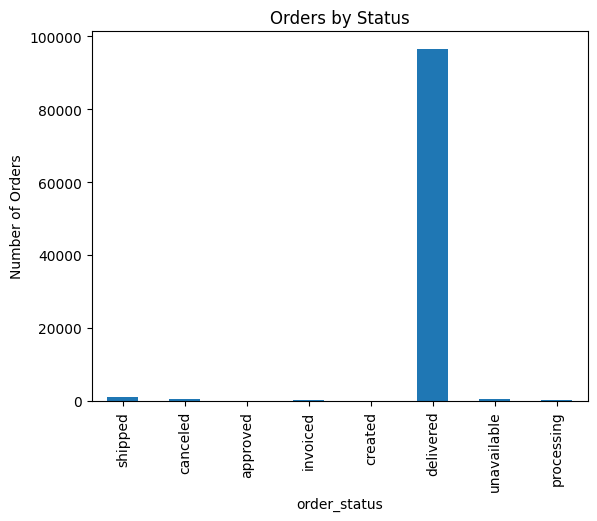

In [ ]:
#Orders by Status Graph
orders_status = orders.groupBy("order_status").count().toPandas()

orders_status.plot(kind="bar", x="order_status", y="count", legend=False)
plt.title("Orders by Status")
plt.ylabel("Number of Orders")
plt.show()

**Key Insights from E-Commerce Order Data Analysis :**

1. The dataset includes 99,441 orders, 99,441 customers, and 32,951 products, giving a comprehensive view of e-commerce transactions.

2. 96,478 orders were delivered, indicating high logistics efficiency and strong order fulfillment performance.

3. Canceled (625) and unavailable (609) orders represent only a small portion of total orders, showing stable order processing.

4. The remaining orders fall under statuses such as processing, shipped, invoiced, approved, and created, representing different stages of the order lifecycle.

5. Major cities like São Paulo and Rio de Janeiro generate the highest number of orders, indicating strong demand in urban regions.

**Graph Visualization :**

This bar chart, created using Python and Matplotlib, shows the distribution of orders across different order statuses. It helps compare how many orders fall into each stage of the order lifecycle and highlights the high number of successfully delivered orders.




